In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import tomllib
from pathlib import Path

from thesis_code.plotting import plot_performance, plot_gradients, InteractiveSpikePlot

In [2]:
work_dir = Path.cwd()
print(work_dir)
with open(work_dir / "config.toml", 'rb') as cfg_file:
    cfg = tomllib.load(cfg_file)

n_trials = cfg["training"]["n_trials"]
def get_data(data_group: str, data_name: str) -> np.ndarray:
    return np.array([np.load(work_dir / f"seed_{i}" / "data_net" / data_group / data_name) for i in range(n_trials)])

c:\Users\emiel\Documents\Study\Thesis\Thesis-Code\important_outputs\2026-10-08_10-04-08-test_run


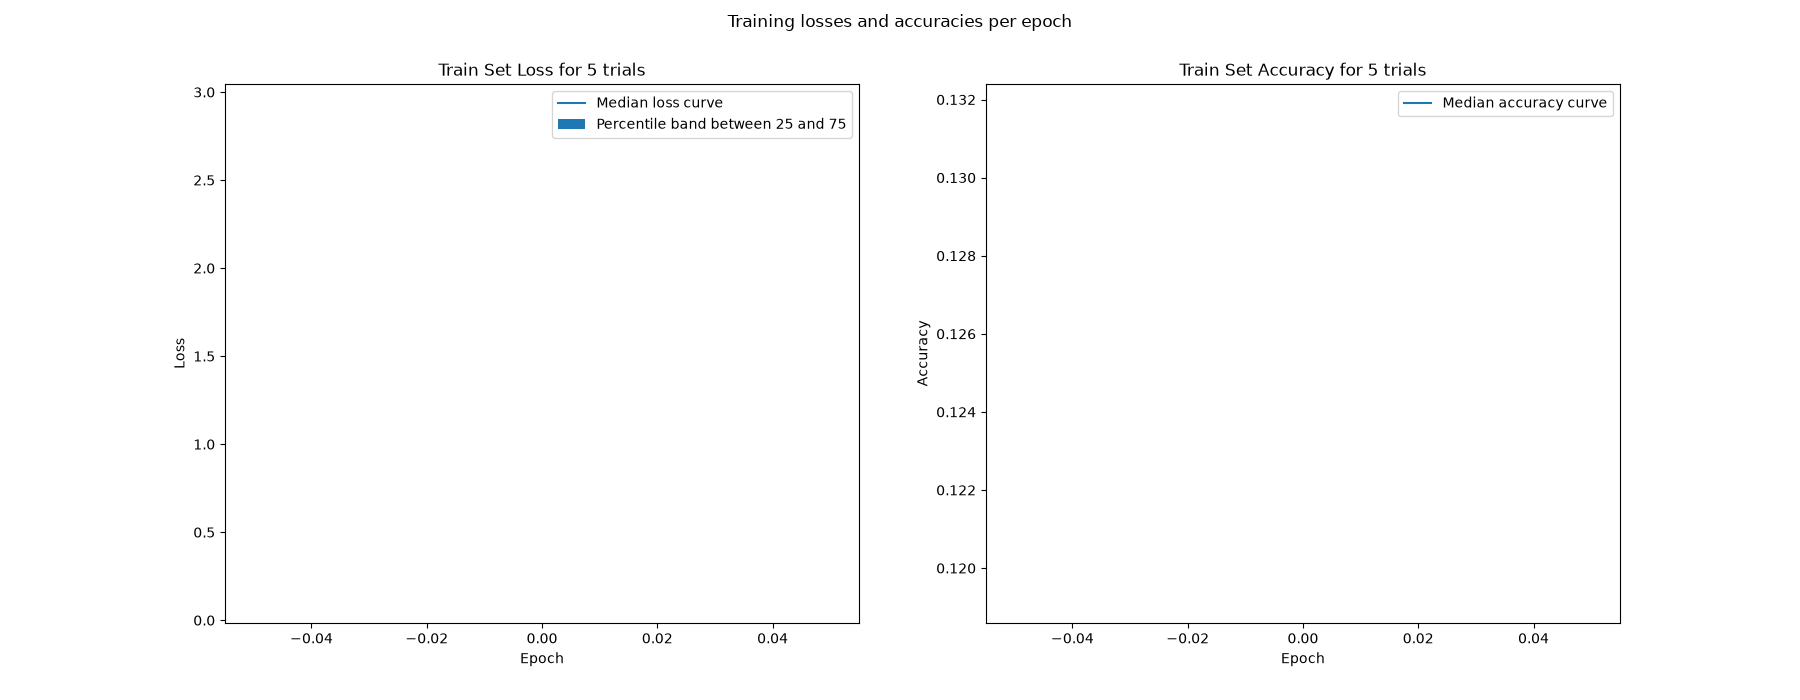

In [3]:
loss_rec = get_data("performance", "loss.npy")
acc_rec = get_data("performance", "acc.npy")
plot_performance(loss_rec, acc_rec)

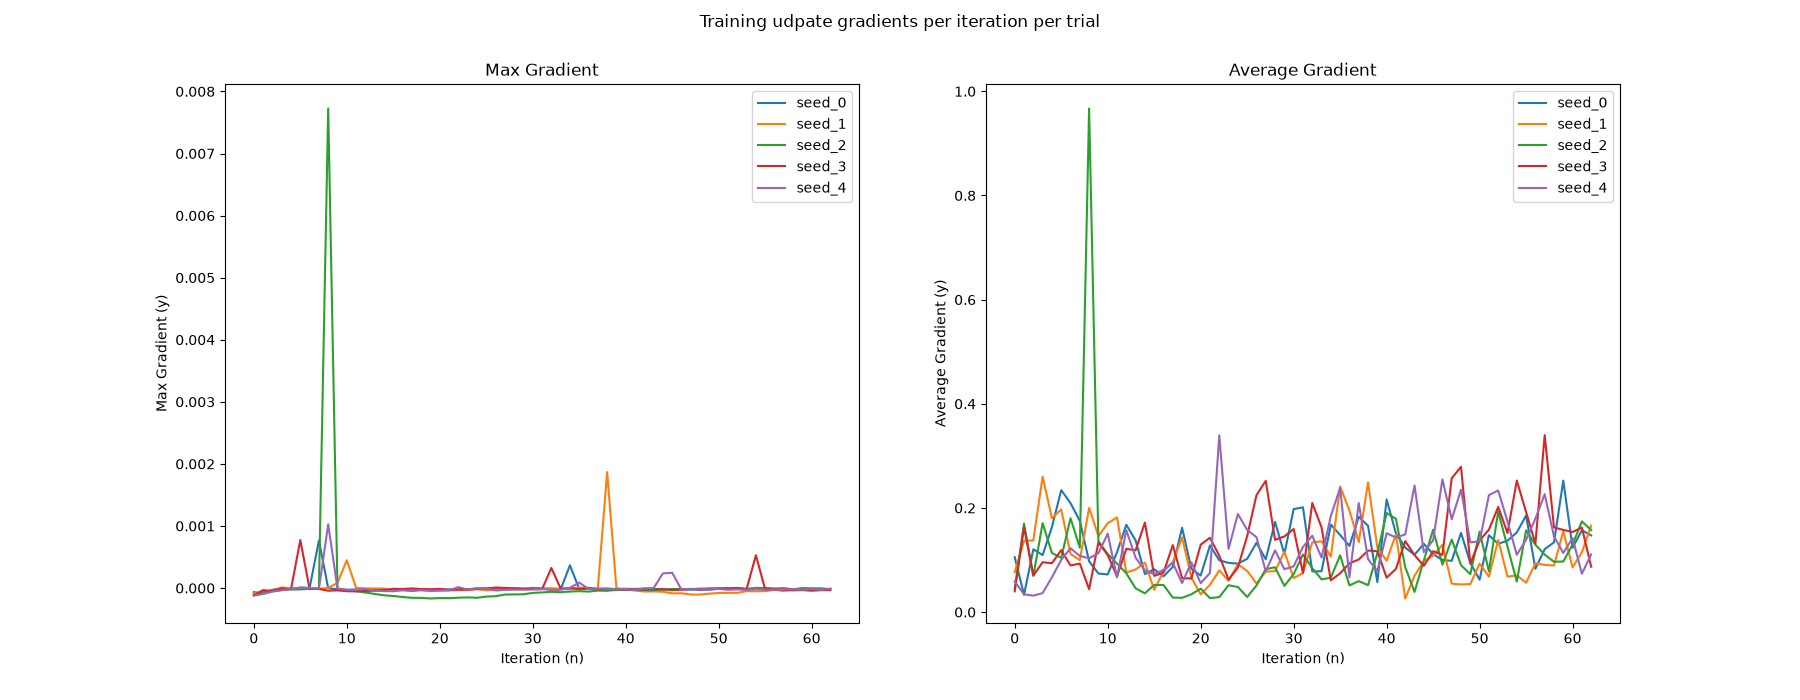

In [4]:
max_grad_rec = get_data("gradients", "avg_grad.npy")
avg_grad_rec = get_data("gradients", "max_grad.npy")
plot_gradients(max_grad_rec, avg_grad_rec)

In [20]:
def plot_weight_matrix(weights: np.ndarray) -> None:
    n_epochs = weights.shape[1]
    fig, axes = plt.subplots(nrows=1, ncols=n_epochs, squeeze=False, figsize=(8, 8 * n_epochs))
    for ax, w_matrix in zip(axes, [*weights[0]]):
        print(w_matrix.shape)
        ax = ax[0]
        im = ax.imshow(w_matrix, cmap="bwr")

    fig.suptitle("Plots of learned weights per training epoch")
    fig.tight_layout()
    fig.colorbar(im)

(5, 1, 256, 700)
(256, 700)


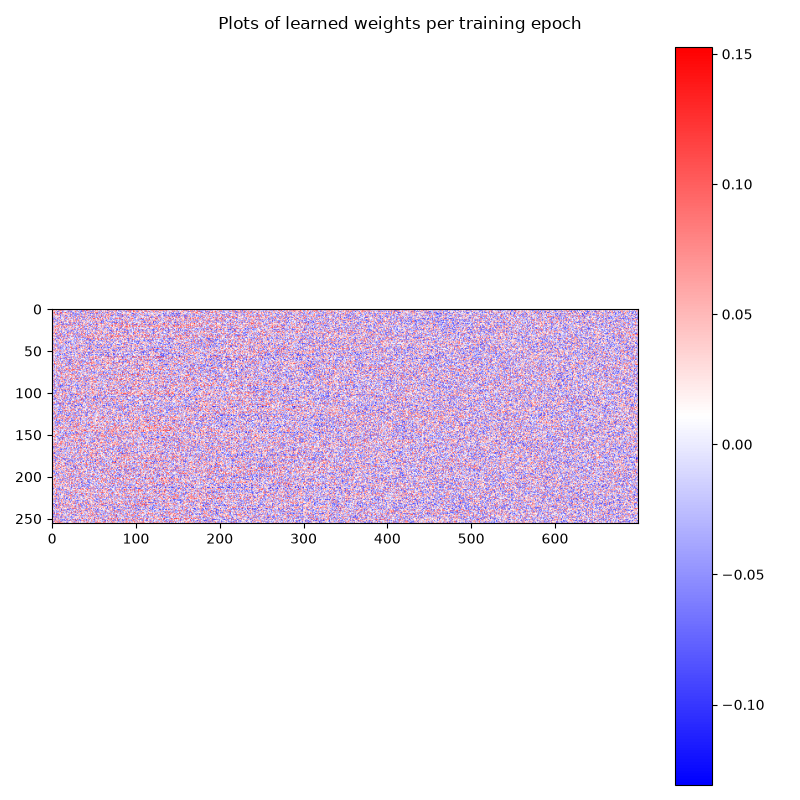

In [21]:
weights_forward_0 = get_data("weights", "weights_forward_0.npy")
weights_forward_1 = get_data("weights", "weights_forward_1.npy")
weights_recurrent_0 = get_data("weights", "weights_recurrent_0.npy")
print(weights_forward_0.shape)
plot_weight_matrix(weights_forward_0)